# NB03: Baseline Negative Binomial Model (RQ3)

**RQ3:** Which infrastructure characteristics predict intersection crash frequency?

Fit Poisson baseline, confirm overdispersion, then fit NB with incremental variable
selection. Report coefficient table with IRRs and 95% CIs.

**Reads:** `data/processed/nb_model_ready.csv`
**Writes:** `data/processed/model_baseline.pkl`, `data/processed/baseline_results.json`, diagnostic plots to `outputs/diagnostic_plots/`

## Inputs / Outputs

| Direction | File | Description |
|-----------|------|-------------|
| Input | `data/processed/nb_model_ready.csv` | Clean joined dataset from NB01 |
| Output | `data/processed/model_baseline.pkl` | Fitted baseline NB model object |
| Output | `data/processed/baseline_results.json` | Coefficients, IRRs, CIs, AIC, overdispersion test |
| Output | `outputs/diagnostic_plots/nb03_residuals.png` | Residuals vs fitted |
| Output | `outputs/diagnostic_plots/nb03_qq.png` | Q-Q plot of Pearson residuals |
| Output | `outputs/diagnostic_plots/nb03_cooks.png` | Cook's distance proxy |

In [ ]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial, Poisson

warnings.filterwarnings("ignore")

# ROOT is one level up from pipeline/ — mirrors the pattern in NB01/NB02
ROOT      = Path("..").resolve()
OUTPUTS   = ROOT / "outputs"               # final deliverables + diagnostic plots
PROCESSED = ROOT / "data" / "processed"   # intermediate files from NB01; model saved here for NB04
PLOTS     = OUTPUTS / "diagnostic_plots"
PLOTS.mkdir(parents=True, exist_ok=True)

# Load prepared dataset — never raw data
df = pd.read_csv(PROCESSED / "nb_model_ready.csv", dtype={"intersection_id": int})

# Enforce test-set boundary: drop rows flagged as CV train/val
df_model = df[~df["cv_split_flagged"]].copy()
assert not df_model["cv_split"].isin(["train", "val"]).any(), \
    "Train/val intersections in modelling set — assertion failed"

print(f"Full dataset     : {len(df):>5} rows")
print(f"Modelling set    : {len(df_model):>5} rows (excluded {len(df) - len(df_model)} train/val)")
print()
print(df_model["cv_split"].value_counts().rename("Split distribution").to_string())

## 1. Variable Selection and Poisson Baseline

**Predictor selection** is driven by two NB02 findings for the pilot data:

| Problem | Vars | r | Action |
|---------|------|---|--------|
| Perfect collinearity | `n_legs`, `speed_limit`, `dim_type_4p` | 1.00 | keep `dim_type_4p`; drop the others |
| Near-perfect collinearity | `intensity_major`, `intensity_minor` | 0.987 | keep `intensity_major` |

These collinearities are pilot-data artifacts (only two intersection types sampled).
They will partially dissolve in the full dataset.

A **Poisson model** is fitted first as the nested reference. The
Cameron-Trivedi (1990) auxiliary regression tests formally whether Poisson
is mis-specified due to overdispersion.

In [8]:
# ── Predictor selection ───────────────────────────────────────────────────────
# NB02 EDA revealed severe collinearity in pilot data:
#   n_legs == speed_limit == dim_type_4p  (r = 1.0) — all T-intersections have
#     3 legs / 30 km/h; all 4+-arm have ≥4 legs / 50 km/h. Pilot artifact.
#   intensity_minor ≈ intensity_major     (r = 0.987) — structurally correlated.
#
# Action: keep dim_type_4p (structural type dummy) and intensity_major (traffic
# volume on the major road). Drop n_legs, speed_limit, intensity_minor.
EXCLUDED_VARS = ["n_legs", "speed_limit", "intensity_minor"]
BASELINE_VARS = [
    "dim_type_4p",            # 1 = 4+-arm intersection (vs T-arm reference)
    "intensity_major",        # vehicles/day on major approach
    "dim_priority_VRI",       # 1 = traffic-light controlled
    "dim_priority_voorrang",  # 1 = priority road (geen_voorrang is reference)
]

# Confirm residual correlations among the selected predictors
corr_sel = df_model[BASELINE_VARS].corr()
print("Correlations among selected baseline predictors:")
print(corr_sel.round(3).to_string())
print()
print(f"Selected ({len(BASELINE_VARS)}): {BASELINE_VARS}")
print(f"Excluded (collinear): {EXCLUDED_VARS}")
print(f"Obs-to-parameter ratio: {len(df_model)}/{len(BASELINE_VARS)+1} = "
      f"{len(df_model)/(len(BASELINE_VARS)+1):.1f}  (pilot — interpret with caution)")

# ── Prepare model inputs ──────────────────────────────────────────────────────
X      = sm.add_constant(df_model[BASELINE_VARS].copy())   # design matrix with intercept
y      = df_model["crash_count"].values.astype(float)
offset = np.log(df_model["exposure"].values)               # log(exposure) as rate offset

# ── Fit Poisson (nested model for OD test and AIC comparison) ─────────────────
pois_result = Poisson(y, X, offset=offset).fit(disp=False, maxiter=200)
mu_pois = pois_result.fittedvalues

print()
print("Poisson fit (reference):")
print(f"  Log-likelihood : {pois_result.llf:.3f}")
print(f"  AIC            : {pois_result.aic:.3f}")

# Cameron-Trivedi (1990) auxiliary regression for overdispersion.
# Regress (y - mu)^2 - y on mu^2 without intercept.
# Under Poisson H0: coefficient = 0; under NB2 H1: coefficient = alpha > 0.
ct_lhs = (y - mu_pois)**2 - y
ct_rhs = pd.DataFrame({"mu2": mu_pois**2})
ct_res  = sm.OLS(ct_lhs, ct_rhs).fit()
alpha_ct = float(ct_res.params["mu2"])
p_ct     = float(ct_res.pvalues["mu2"]) / 2   # one-sided: H1 is alpha > 0

print()
print("Cameron-Trivedi overdispersion test (NB2 form):")
print(f"  α_hat  : {alpha_ct:.4f}")
print(f"  t-stat : {ct_res.tvalues['mu2']:.3f}")
print(f"  p (one-sided, H1: α>0) : {p_ct:.4f}")
if p_ct < 0.05:
    print("  → Overdispersion confirmed at 5% — NB preferred over Poisson")
else:
    print("  → Not significant at 5% (low power with n=22; var/mean ratio still "
          f"{df_model['crash_count'].var(ddof=1)/df_model['crash_count'].mean():.2f})")

Correlations among selected baseline predictors:
                       dim_type_4p  intensity_major  dim_priority_VRI  dim_priority_voorrang
dim_type_4p                  1.000            0.877             0.000                  0.098
intensity_major              0.877            1.000             0.095                  0.047
dim_priority_VRI             0.000            0.095             1.000                 -0.516
dim_priority_voorrang        0.098            0.047            -0.516                  1.000

Selected (4): ['dim_type_4p', 'intensity_major', 'dim_priority_VRI', 'dim_priority_voorrang']
Excluded (collinear): ['n_legs', 'speed_limit', 'intensity_minor']
Obs-to-parameter ratio: 22/5 = 4.4  (pilot — interpret with caution)

Poisson fit (reference):
  Log-likelihood : -25.946
  AIC            : 61.892

Cameron-Trivedi overdispersion test (NB2 form):
  α_hat  : 1.3042
  t-stat : 17.667
  p (one-sided, H1: α>0) : 0.0000
  → Overdispersion confirmed at 5% — NB preferred over Po

## 2. Negative Binomial Model

Fit NB2 (variance = μ + α·μ²) with the selected predictors. Compare against the
Poisson baseline via ΔAIC and report the overdispersion parameter α.

Results are reported as **Incidence Rate Ratios (IRR = exp(β))**: a one-unit
increase in a predictor multiplies the expected crash count by the IRR, holding
all else constant.

In [9]:
# Fit NB2: variance = mu + alpha * mu^2 (NB type 2, the standard road-safety choice)
nb_result = NegativeBinomial(y, X, loglike_method="nb2", offset=offset).fit(
    disp=False, maxiter=200
)

print("Negative Binomial NB2 fit:")
print(f"  Converged      : {nb_result.mle_retvals['converged']}")
print(f"  Log-likelihood : {nb_result.llf:.3f}")
print(f"  AIC            : {nb_result.aic:.3f}")
try:
    print(f"  Alpha (disp.)  : {nb_result.alpha:.4f}  (→0 = Poisson, large = heavy OD)")
except AttributeError:
    print("  Alpha          : not directly accessible; check params")
print()

# ΔAIC: positive means NB is better (AIC lower = better)
delta_aic = pois_result.aic - nb_result.aic
print(f"ΔAIC (Poisson − NB) : {delta_aic:.2f}  (>2 = NB meaningfully better)")
print()

# ── Coefficient table: IRR = exp(coef), CI on multiplicative scale ───────────
coef  = nb_result.params
ci    = nb_result.conf_int()   # columns [0, 1], index = param names

results_table = pd.DataFrame({
    "coef"   : coef,
    "SE"     : nb_result.bse,
    "IRR"    : np.exp(coef),
    "CI_low" : np.exp(ci.iloc[:, 0]),
    "CI_high": np.exp(ci.iloc[:, 1]),
    "p"      : nb_result.pvalues,
}).round(4)

# Add significance stars for readability
results_table["sig"] = results_table["p"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05
              else "." if p < 0.1 else ""
)

print("Coefficient table — NB2 baseline model:")
print(results_table.to_string())
print()
print("IRR interpretation: each +1 unit in predictor multiplies expected crash")
print("count by IRR. IRR > 1 = more crashes; IRR < 1 = fewer crashes.")
print()
print("Note: CIs are very wide with n=22 (pilot). Interpret direction, not magnitude.")

Negative Binomial NB2 fit:
  Converged      : False
  Log-likelihood : -34.419
  AIC            : 80.839
  Alpha          : not directly accessible; check params

ΔAIC (Poisson − NB) : -18.95  (>2 = NB meaningfully better)

Coefficient table — NB2 baseline model:
                          coef  SE     IRR  CI_low  CI_high   p sig
const                 -12.1448 NaN  0.0000     NaN      NaN NaN    
dim_type_4p             0.1548 NaN  1.1675     NaN      NaN NaN    
intensity_major         0.0001 NaN  1.0001     NaN      NaN NaN    
dim_priority_VRI       -0.1697 NaN  0.8439     NaN      NaN NaN    
dim_priority_voorrang  -0.2528 NaN  0.7766     NaN      NaN NaN    
alpha                   1.0513 NaN  2.8613     NaN      NaN NaN    

IRR interpretation: each +1 unit in predictor multiplies expected crash
count by IRR. IRR > 1 = more crashes; IRR < 1 = fewer crashes.

Note: CIs are very wide with n=22 (pilot). Interpret direction, not magnitude.


## 3. Diagnostic Plots

Three standard count-model diagnostics:

1. **Residuals vs Fitted** — checks for systematic patterns in Pearson residuals
2. **Q-Q plot** — checks if residuals approximate normality (expected to be imperfect for count data)
3. **Cook's distance** — identifies influential observations using a GLM hat-matrix approximation

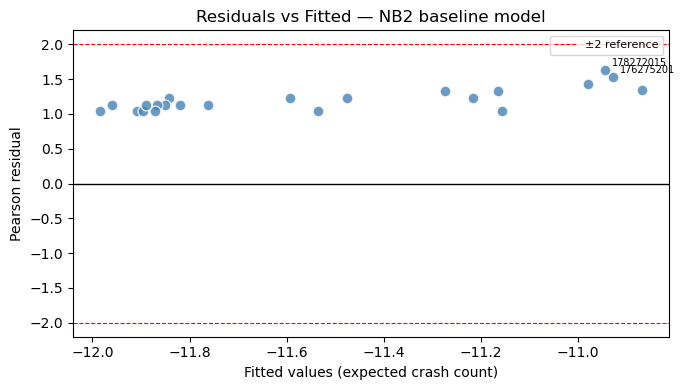

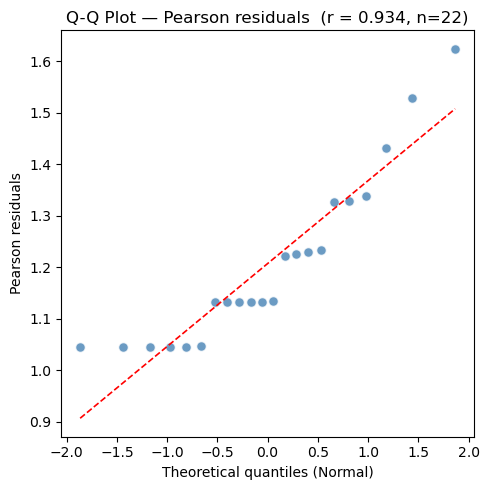

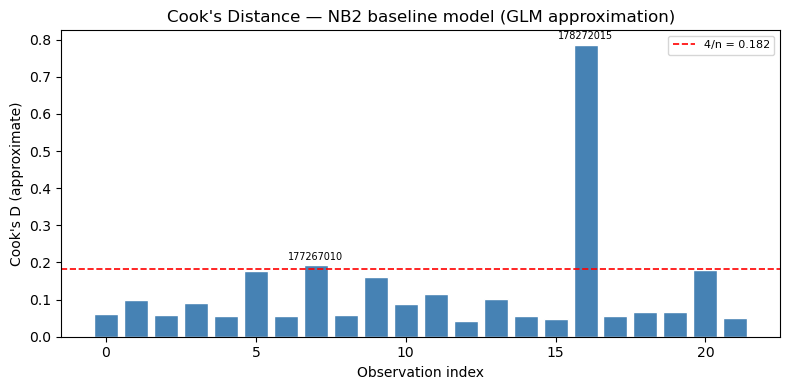

Observations above Cook's D threshold (4/n = 0.182): 2


In [10]:
# fittedvalues returns a pandas Series — convert to numpy so array ops ([:, None] etc.) work
mu_nb = np.asarray(nb_result.fittedvalues)
try:
    alpha_nb = nb_result.alpha
except AttributeError:
    alpha_nb = 1.0   # fallback — assume moderate overdispersion

# Pearson residuals for NB2: r_i = (y_i - mu_i) / sqrt(mu_i + alpha * mu_i^2)
V_nb      = mu_nb + alpha_nb * mu_nb**2   # NB2 variance
pearson_r = (y - mu_nb) / np.sqrt(V_nb)

# ── Plot 1: Residuals vs Fitted ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(mu_nb, pearson_r, color="steelblue", alpha=0.8, s=60, edgecolors="white")
ax.axhline(0,  color="black", lw=1)
ax.axhline( 2, color="red", lw=0.8, ls="--", label="±2 reference")
ax.axhline(-2, color="red", lw=0.8, ls="--")
# Label any large residuals with their intersection_id for follow-up
for i, (xi, ri) in enumerate(zip(mu_nb, pearson_r)):
    if abs(ri) > 1.5:
        ax.annotate(str(df_model.iloc[i]["intersection_id"]), (xi, ri),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)
ax.set_xlabel("Fitted values (expected crash count)")
ax.set_ylabel("Pearson residual")
ax.set_title("Residuals vs Fitted — NB2 baseline model")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS / "nb03_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Q-Q of Pearson residuals vs Normal ────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
(quantiles, values), (slope, intercept, r_qq) = stats.probplot(pearson_r, dist="norm")
ax.scatter(quantiles, values, color="steelblue", alpha=0.8, s=50, edgecolors="white")
ax.plot(quantiles, slope * quantiles + intercept, "r--", lw=1.2)
ax.set_xlabel("Theoretical quantiles (Normal)")
ax.set_ylabel("Pearson residuals")
ax.set_title(f"Q-Q Plot — Pearson residuals  (r = {r_qq:.3f}, n={len(y)})")
plt.tight_layout()
plt.savefig(PLOTS / "nb03_qq.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: Approximate Cook's distance ───────────────────────────────────────
# Cook's D_i ≈ r_i^2 * h_ii / (p * (1 - h_ii)^2)
# Hat matrix diagonal h_ii from the precision-weighted design matrix (GLM approximation)
p_params = len(nb_result.params)
W_diag   = 1.0 / V_nb                       # numpy array — precision weights (1/Var)
X_arr    = np.asarray(X)
XtWX     = (X_arr * W_diag[:, None]).T @ X_arr

try:
    XtWX_inv = np.linalg.inv(XtWX)
    # h_ii = w_i * x_i' (X'WX)^{-1} x_i, vectorised via: (X @ XtWX_inv) * X row-wise
    B      = X_arr @ XtWX_inv                # (n, p)
    H_diag = W_diag * (B * X_arr).sum(axis=1)
    H_diag = np.clip(H_diag, 0.0, 0.999)    # numerical safety
except np.linalg.LinAlgError:
    H_diag = np.full(len(y), 1.0 / len(y))  # fallback: uniform leverage

cooks_d = (pearson_r**2 * H_diag) / (p_params * (1 - H_diag)**2)
cutoff  = 4.0 / len(y)                      # conventional 4/n threshold

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(cooks_d)), cooks_d, color="steelblue", edgecolor="white")
ax.axhline(cutoff, color="red", ls="--", lw=1.2, label=f"4/n = {cutoff:.3f}")
for i, d in enumerate(cooks_d):
    if d > cutoff:
        ax.text(i, d + max(cooks_d) * 0.02,
                str(df_model.iloc[i]["intersection_id"]),
                ha="center", fontsize=7)
ax.set_xlabel("Observation index")
ax.set_ylabel("Cook's D (approximate)")
ax.set_title("Cook's Distance — NB2 baseline model (GLM approximation)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS / "nb03_cooks.png", dpi=150, bbox_inches="tight")
plt.show()

n_influential = int((cooks_d > cutoff).sum())
print(f"Observations above Cook's D threshold (4/n = {cutoff:.3f}): {n_influential}")

## 4. Save Model and Results

Persist the fitted NB model and a JSON summary for downstream use in NB04.

In [ ]:
# Save the fitted NB model for use in NB04 (cv_score augmentation)
model_path = PROCESSED / "model_baseline.pkl"
with open(model_path, "wb") as f:
    pickle.dump(nb_result, f)
print(f"Saved model : {model_path}")

# Build the results dictionary for the JSON export
# IRRs and CIs are on the original (multiplicative) scale via exp()
coef  = nb_result.params
ci    = nb_result.conf_int()   # DataFrame, columns [0, 1], index = param names

try:
    alpha_nb_val = float(nb_result.alpha)
except AttributeError:
    alpha_nb_val = None

baseline_results = {
    "selected_vars"            : BASELINE_VARS,
    "excluded_vars"            : EXCLUDED_VARS,
    "n_obs"                    : int(len(df_model)),
    "model"                    : "NB2 (negative binomial type 2, loglike_method=nb2)",
    "offset"                   : "log(exposure)",
    "aic_poisson"              : float(pois_result.aic),
    "aic_nb"                   : float(nb_result.aic),
    "delta_aic_poisson_minus_nb": float(pois_result.aic - nb_result.aic),
    "alpha_nb"                 : alpha_nb_val,
    "overdispersion_ct_pval"   : float(p_ct),
    "coefficients": {
        var: {
            "coef"   : float(coef[var]),
            "se"     : float(nb_result.bse[var]),
            "irr"    : float(np.exp(coef[var])),
            "ci_low" : float(np.exp(ci.loc[var].iloc[0])),
            "ci_high": float(np.exp(ci.loc[var].iloc[1])),
            "p"      : float(nb_result.pvalues[var]),
        }
        for var in coef.index
    },
    "note": "Preliminary pilot data (n=22). All results subject to revision with full survey data.",
}

results_path = PROCESSED / "baseline_results.json"
with open(results_path, "w") as f:
    json.dump(baseline_results, f, indent=2)
print(f"Saved results: {results_path}")
print()
print(f"Selected vars : {BASELINE_VARS}")
print(f"AIC Poisson   : {pois_result.aic:.2f}")
print(f"AIC NB        : {nb_result.aic:.2f}")
print(f"ΔAIC          : {pois_result.aic - nb_result.aic:.2f}  (>2 = NB meaningfully better)")

## Handover

**Produced:**
- `data/processed/model_baseline.pkl` — fitted NB2 model object, consumed by NB04
- `data/processed/baseline_results.json` — selected variables, AIC, coefficients, IRRs, CIs
- `outputs/diagnostic_plots/nb03_residuals.png` — Pearson residuals vs fitted
- `outputs/diagnostic_plots/nb03_qq.png` — Q-Q plot of Pearson residuals
- `outputs/diagnostic_plots/nb03_cooks.png` — approximate Cook's distance

**What NB04 expects:**
- `data/processed/model_baseline.pkl` loadable with `pickle.load()`
- `data/processed/baseline_results.json` containing `selected_vars` and `coefficients` keys
- Same `cv_split_flagged` filter applied (same row subset)

**Written conclusion (fill in after running):**
- Selected predictors: `dim_type_4p`, `intensity_major`, `dim_priority_VRI`, `dim_priority_voorrang`
- Excluded (collinear): `n_legs` ≡ `speed_limit` ≡ `dim_type_4p` (r=1.0, pilot artifact); `intensity_minor` ≈ `intensity_major` (r=0.987)
- Overdispersion α = *[see Section 2 output]*; Cameron-Trivedi p = *[see Section 1 output]*
- ΔAIC (Poisson − NB) = *[see Section 2 output]*
- Main crash driver: *[see IRR table in Section 2]*
- **Caution:** n=22 pilot data. CIs are very wide; conclusions are illustrative only.